In [31]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scienceplots
import scipy
import warnings
warnings.filterwarnings("ignore")

plt.style.use(["science","no-latex"])

In [20]:
from sympy.abc import f,t,tau

In [21]:
y=sp.sinc(f)

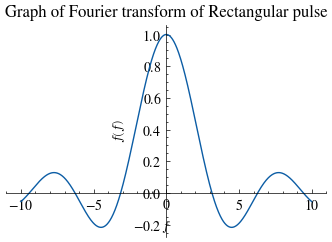

In [22]:
sp.plot(y,title="Graph of Fourier transform of Rectangular pulse")
plt.show()

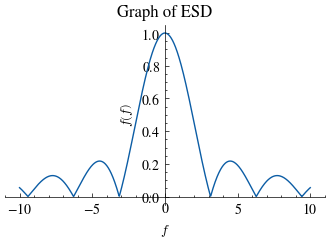

In [23]:
#plotting its magnitude
sp.plot(sp.Abs(y),title="Graph of ESD")
plt.show()

In [24]:
g=sp.Heaviside(t+1)-sp.Heaviside(t-1)
g

-Heaviside(t - 1) + Heaviside(t + 1)

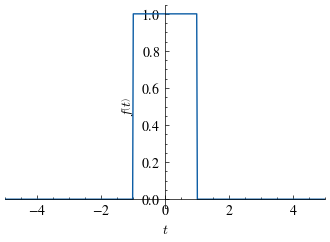

In [25]:
sp.plot(g,xlim=[-5,5])
plt.show()


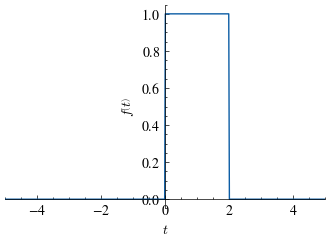

In [26]:
#shifted by tau
h=g.subs(t,t-1)
sp.plot(h,xlim=[-5,5])
plt.show()

In [27]:
hg=g*h.subs(t,t-tau)

In [28]:
hg

(-Heaviside(t - 1) + Heaviside(t + 1))*(Heaviside(t - tau) - Heaviside(t - tau - 2))

In [33]:
hg_num=sp.lambdify([t,tau],hg,modules=["numpy","scipy"])


<function _lambdifygenerated(t, tau)>

In [35]:
#perform numerically 
g=[1,1,1,1,1,1]
corr=np.correlate(g,g,mode="full")

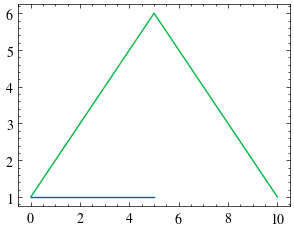

In [38]:
plt.plot(g)
plt.plot(corr)
plt.show()

Input Energy = 0.25050033281692474
Output Energy = 0.22653050829901764
Percentage = 90.43122049046332


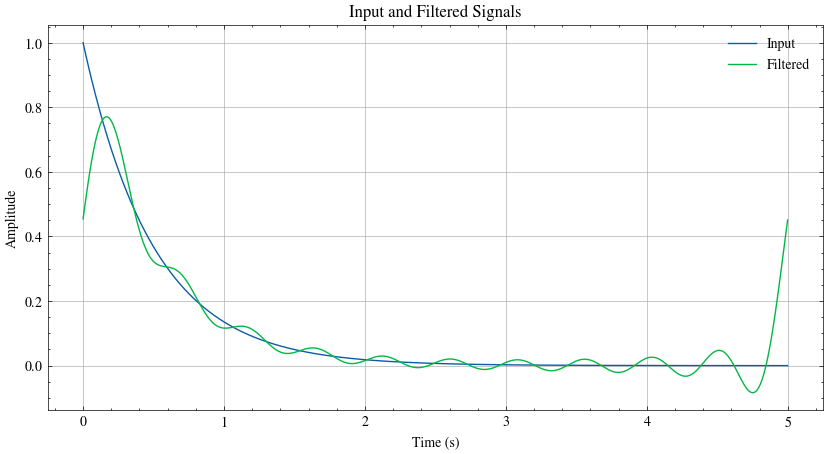

In [39]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 1000              # Sampling frequency
dt = 1/Fs
t = np.arange(0,5,dt)

# Signal
x = np.exp(-2*t)

# FFT
N = len(x)
X = np.fft.fft(x)

# Frequency vector
f = np.fft.fftfreq(N,dt)

# Cutoff frequency
fc = 2.01

# Ideal LPF
H = np.zeros(N)
H[np.abs(f)<=fc] = 1

# Filter
Y = X*H

# Inverse FFT
y = np.real(np.fft.ifft(Y))

# Energies
Ex = np.sum(x**2)*dt
Ey = np.sum(y**2)*dt

print("Input Energy =",Ex)
print("Output Energy =",Ey)
print("Percentage =",Ey/Ex*100)

plt.figure(figsize=(10,5))
plt.plot(t,x,label='Input')
plt.plot(t,y,label='Filtered')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Input and Filtered Signals')
plt.legend()
plt.grid(True)
plt.show()